# Conttest 3 - Main part

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import scipy.stats as stats
from scipy.stats import gmean
from scipy.stats import norm
from scipy import special
from scipy.optimize import curve_fit
from scipy.special import expit
from scipy.optimize import fsolve

#import NDL
%run NDL.ipynb

In [2]:
#Input
path="data.csv" #CSV file
CorrF = 0.82 # sensor correctur factor

In [3]:
# Read CSV
df = pd.read_csv(path, decimal=",")
df = df.rename(columns={df.columns[0]: "Time"})

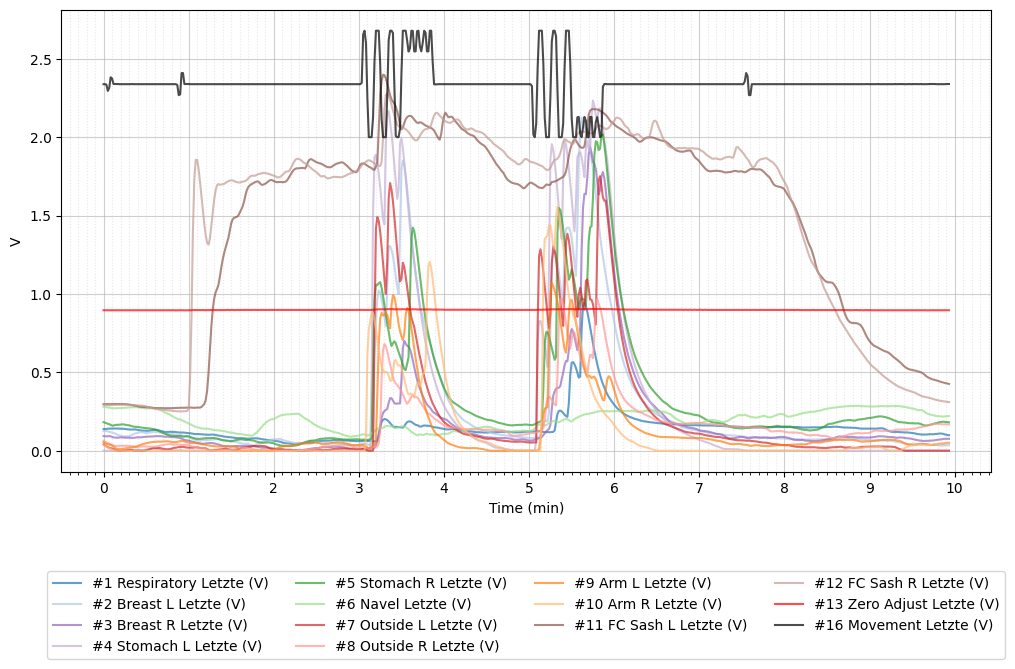

In [4]:
# Plot raw data
time = pd.to_timedelta(df.iloc[:,0])
time_min = time.dt.total_seconds() / 60

fig, ax = plt.subplots(figsize=(12,6))

colors =['#1f77b4','#aec7e8','#9467bd','#c5b0d5',
 '#2ca02c','#98df8a','#d62728','#ff9896',
 '#ff7f0e','#ffbb78','#8c564b','#c49c94',
 '#ff0000','#000000']
for col, c in zip(df.columns[1:15], colors):
    ax.plot(time_min, df[col], label=col,  color=c, alpha=0.7)

ax.set_xlabel("Time (min)")
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.grid(which="major", linestyle="-", alpha=0.6)
ax.grid(which="minor", linestyle=":", alpha=0.3)

ax.set_ylabel("V")
ax.legend(loc="upper center", bbox_to_anchor=(0.5,-0.2), ncol=4)
plt.show()

In [5]:
#phases
move = df.columns[14]  # movement channel

# detect peaks
peaks = ((df[move].diff() > 0.001) & (df[move].diff().shift(1) > 0.001))
peak_values = df.loc[peaks]

# convert time column to minutes
time_min = pd.to_timedelta(df.iloc[:,0]).dt.total_seconds() / 60

# peaks defining the first cycle
t3 = time_min.iloc[peak_values.index[2]]
t4 = time_min.iloc[peak_values.index[13]]

# compute end of second cycle
target_time = t3 + 2 * (t4 - t3)

# find closest time position
pos = (time_min - target_time).abs().idxmin()

# row at computed position
result_row = df.loc[[pos]]

# select peaks for plotting / phase boundaries
selected_peaks = pd.concat([
    peak_values.head(3),   # first 3 peaks
    result_row,            # computed second-cycle end
    peak_values.tail(1),   # last peak
    df.tail(1)             # final dataset point
]).drop_duplicates().sort_index()

index_start = selected_peaks.index[0]
index_induction =selected_peaks.index[1]
index_cycle_start = selected_peaks.index[2]
index_cycle_end = selected_peaks.index[3]
index_purge = selected_peaks.index[4]
index_end = selected_peaks.index[5]

In [6]:
#Variables
Z_adj = 1
LoDmin=0.01
LoQmin=0.033

# y_ppm= CofA*e^(CofB*x_volt) - Calibration IPA/mVolt 24/02/21 EPFL
F_IPA = np.array([0.484, 1.465, 2.714, 6.355, 14.624, 32.159])
F_ppm = np.array([0.157, 0.350, 0.523, 0.786, 1.085, 1.354])
ln_IPA = np.log(F_IPA)
# linear regression
CofB, intercept, r, p, std_err = linregress(F_ppm , ln_IPA)
CofA = np.exp(intercept)

#offset 
OffV = df.iloc[:index_induction-1, 1:13].mean()
LoQV = 10* df.iloc[29:index_induction-2, 1:13].std()
LoQ=   np.maximum(LoDmin, 10**(LoQV * CorrF) - Z_adj)

In [7]:
# Volt to ppm
for col in df.columns[1:13]:   # columns 2–14
    new_col = col[:-4] 
    df[new_col + " (ppm)"] = np.maximum(
        0.00001,
        10**((df[col] - OffV[col]) * CorrF) - Z_adj
    )
#df.head()

In [8]:
#Acute risk criteria (peak) - CT
max_ct = df.iloc[index_start:index_induction , 15:23].max()
count1 = (max_ct > 1).sum() #Nb of sensors over 1 ppm
CT = "success" if count1 < 1 else "fail"

print(count1, CT)

0 success


In [9]:
#Acute risk criteria (peak) - ART
lookup = pd.DataFrame({
    "Peak_10": [0,1,1,2,2,3,2,3,4,3,3,4,5],
    "Peak_100":   [0,0,1,0,1,0,2,1,0,2,3,1,0],    
    "ART":   [3,3,2,2,2,2,1,1,1,0,0,0,0]
})
lookup_dict = lookup.set_index(["Peak_10","Peak_100"])["ART"].to_dict()
def art_def(p10, p100):
    return lookup_dict.get((p10,p100), None)

max_art = df.iloc[index_cycle_start:index_cycle_end , 15:23].max()
count10 = (max_art > 10).sum() #Nb of sensors over 10 ppm
count100 = (max_art > 100).sum() #Nb of sensors over 100 ppm
ART=art_def(count10,count100)

print(ART)

0


In [10]:
def OdehCL(nn, oel, M, sd, u):
    """
    Odeh & Evans rational approximation for the standard normal CDF limits
    nn : sample size
    oel : value
    M : mean (ln)
    sd : standard deviation
    u : 1 -> UCL, 0 -> LCL
    """
    z = (np.log(oel) - M) / sd
    n = nn - 2

    Wcoef = [
        [0.122639, 0.17093583, 0.20527676, 0.23087629, 0.25087349, 0.26701314, 0.28035886, 0.29158511],
        [-1.183888, -0.36372227, -0.3756623, -0.32948211, -0.30146272, -0.26555197, -0.21322137, -0.14267075],
        [-0.30512797, -0.28537457, -0.33810835, -0.36170947, -0.3787192, -0.38705351, -0.38608727, -0.37596357],
        [1.025662, 0.34851212, 0.36738495, 0.35945667, 0.3687124, 0.38401727, 0.40265771, 0.41758212],
        [0.30466959, 0.16073371, 0.20373584, 0.21196252, 0.22058761, 0.22384309, 0.22000682, 0.2072291],
        [-0.32067478, 0.054071371, 0.018923968, 0.019458266, 0.016283799, 0.015667728, 0.018042944, 0.023635477],
        [-0.1511292, -0.025966434, -0.049770351, -0.053579348, -0.060450757, -0.066696572, -0.071663981, -0.073405376],
        [0.061852348, 0.002995818, 0.011064939, 0.015386764, 0.020005908, 0.024962675, 0.030244939, 0.03496479],
        [0.036997109, -0.005001987, 0.002434374, 0.004273494, 0.007408279, 0.010898192, 0.014749941, 0.018251034],
        [-0.002372369, 0.001633161, 0.000857204, 0.00075015, 0.000398927, -0.0000423757, -0.000600418, -0.001192484],
        [-0.003562442, 0.001421525, 0.00050349, 0.000194275, -0.000279673, -0.000834117, -0.001492028, -0.002165199]
    ]

    lcl = (
        Wcoef[0][n] + Wcoef[2][n]*z + Wcoef[4][n]*(z**2) +
        Wcoef[6][n]*(z**3) + Wcoef[8][n]*(z**4) + Wcoef[10][n]*(z**5)
    ) / (
        1 + Wcoef[1][n]*z + Wcoef[3][n]*(z**2) +
        Wcoef[5][n]*(z**3) + Wcoef[7][n]*(z**4) + Wcoef[9][n]*(z**5)
    )

    if z > 6:
        z = 6

    z_neg = -z

    ucl = 1 - (
        (Wcoef[0][n] + Wcoef[2][n]*z_neg + Wcoef[4][n]*(z_neg**2) +
         Wcoef[6][n]*(z_neg**3) + Wcoef[8][n]*(z_neg**4) + Wcoef[10][n]*(z_neg**5))
        /
        (1 + Wcoef[1][n]*z_neg + Wcoef[3][n]*(z_neg**2) +
         Wcoef[5][n]*(z_neg**3) + Wcoef[7][n]*(z_neg**4) + Wcoef[9][n]*(z_neg**5))
    )

    return lcl if u == 0 else ucl

In [11]:
#NDL
crt_sensor = df.iloc[index_cycle_start:index_cycle_end, 15:23].mean() 
LoQ8 = LoQ.iloc[:8] 
data = pd.DataFrame({
    "Value": np.where(crt_sensor.values < LoQ8.values, "<"+ str(LoDmin), crt_sensor.values)
})
dataNDL = CheckNDL(data)["ValueNDL"].to_numpy()

In [12]:
#Chronic risk criteria- CRT
data_ln = np.log(dataNDL)
CRT_1 = OdehCL(nn=8, oel=1, M=data_ln.mean(), sd=data_ln.std(), u=1)
CRT_10 = OdehCL(nn=8, oel=10, M=data_ln.mean(), sd=data_ln.std(), u=1)
CRT_100 = OdehCL(nn=8, oel=100, M=data_ln.mean(), sd=data_ln.std(), u=1)

CRT = 3 if CRT_1 < 0.05 else 2 if CRT_10 < 0.05 else 1  if CRT_100 < 0.05 else 0

print(CRT)

0


In [13]:
#CP
cp_table = {
    (0,0):0,(0,1):0,(0,2):0,(0,3):0,
    (1,0):0,(2,0):0,(3,0):0,
    (1,1):1,(1,2):1,(1,3):1,
    (2,1):2,(3,1):2,
    (2,2):2,(2,3):2,(3,2):2,
    (3,3):3
}

def get_cp(art, crt):
    return cp_table[(art, crt)]

CP = get_cp(ART, CRT)
print(CP)

0


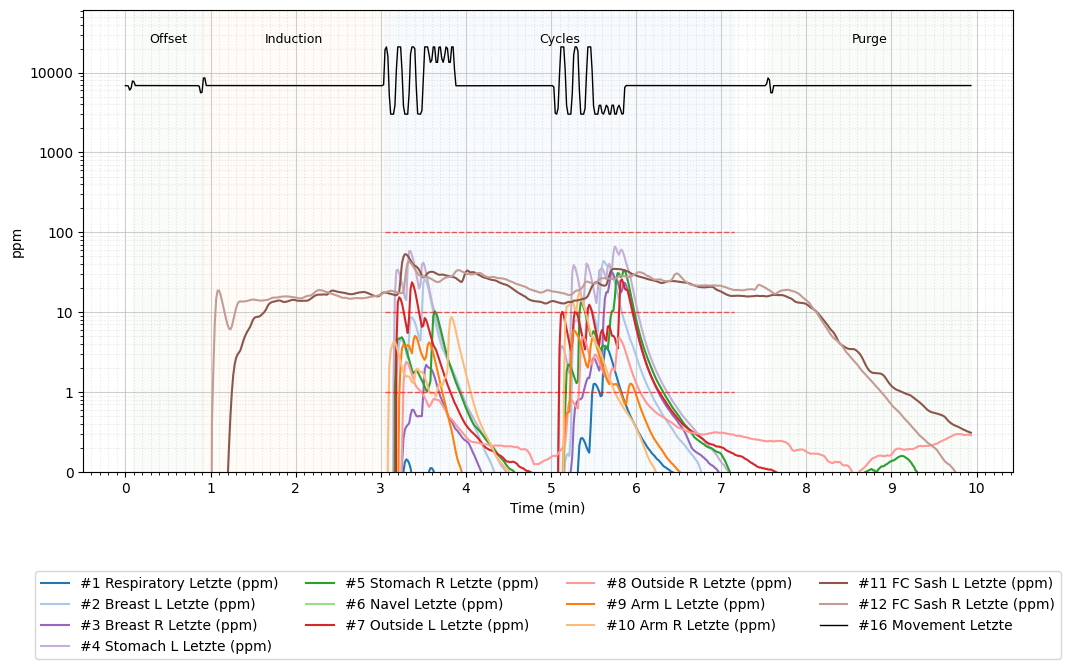

In [14]:
# Plot ppm - all sensor
time = pd.to_timedelta(df.iloc[:,0])
time_min = time.dt.total_seconds() / 60

fig, ax = plt.subplots(figsize=(12,6))

colors =['#1f77b4','#aec7e8','#9467bd','#c5b0d5',
 '#2ca02c','#98df8a','#d62728','#ff9896',
 '#ff7f0e','#ffbb78','#8c564b','#c49c94',
 '#ff0000','#000000']
for col, c in zip(df.columns[15:27], colors):
    ax.plot(time_min, df[col], label=col, color=c)

#movement
ax.plot(time_min, (df[move]**10)+2000 , label=f"{move[:-4]}", linewidth=1, color="black")

#phases
time_peaks = pd.to_timedelta(selected_peaks.iloc[:,0])
peak_time_min = pd.to_timedelta(time_peaks).dt.total_seconds()/60
"""
for tp in peak_time_min:
    ax.axvline(tp, color="red", linestyle="--",  linewidth=1, alpha=0.6)
"""
phase_colors = ["#e8f5e9", "#fff3e0", "#e3f2fd", "#ffffff", "#e8f5e9"]
phase_label = ["Offset", "Induction", "Cycles","","Purge"]
peak_times = peak_time_min.values
for i in range(len(peak_times) - 1):
    ax.axvspan(
        peak_times[i],
        peak_times[i+1],
        color=phase_colors[i % len(phase_colors)],
        alpha=0.25
    )
for i in range(len(peak_times)-1):
    mid = (peak_times[i] + peak_times[i+1]) / 2
    ax.text(mid, ax.get_ylim()[1],phase_label[i],
            ha="center", va="bottom", fontsize=9)
#OEL
ax.hlines(y=1, xmin= peak_times[2], xmax= peak_times[3], color="red", linestyle="--",  linewidth=1, alpha=0.6)
ax.hlines(y=10, xmin= peak_times[2], xmax= peak_times[3], color="red", linestyle="--",  linewidth=1, alpha=0.6)
ax.hlines(y=100, xmin= peak_times[2], xmax= peak_times[3], color="red", linestyle="--",  linewidth=1, alpha=0.6)

# axes
ax.set(
    xlabel="Time (min)",
    ylabel="ppm",
    yscale="log"
)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

ax.set_ylim(bottom=0.1)
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10, subs=range(2,10)))

ax.grid(which="major", linestyle="-", alpha=0.6)
ax.grid(which="minor", linestyle=":", alpha=0.3)
ax.legend(loc="upper center", bbox_to_anchor=(0.5,-0.2), ncol=4)
plt.show()

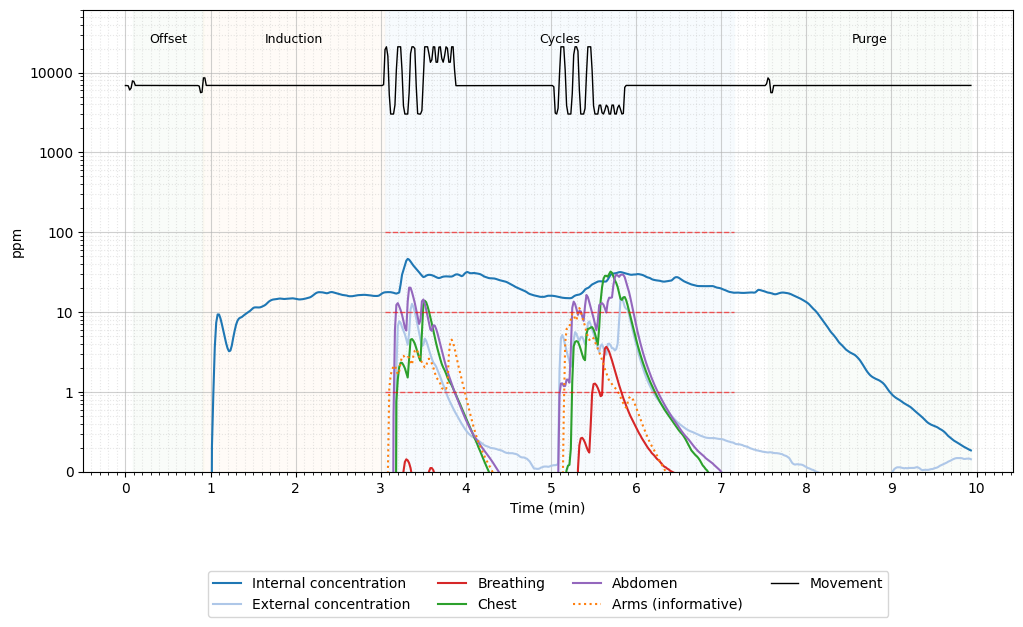

In [15]:
# Plot ppm - summary
df["Internal concentration"] = df.iloc[:, [25,26]].mean(axis=1)
df["External concentration"] = df.iloc[:, [21,22]].mean(axis=1)
df["Breathing"] = df.iloc[:, 15]
df["Chest"] = df.iloc[:, [16,17]].mean(axis=1)
df["Abdomen"] = df.iloc[:, [18,19,20]].mean(axis=1)
df["Arms (informative)"] = df.iloc[:, [23,24]].mean(axis=1)
df["Move"] = df.iloc[:,14]

time_min = pd.to_timedelta(df.iloc[:,0]).dt.total_seconds() / 60

fig, ax = plt.subplots(figsize=(12,6))

signals = [
    "Internal concentration",
    "External concentration",
    "Breathing",
    "Chest",
    "Abdomen",
    "Arms (informative)"
]

colors = [
'#1f77b4','#aec7e8','#d62728','#2ca02c',
'#9467bd','#ff7f0e','#d62728'
]


for i, (col, c) in enumerate(zip(signals, colors)):
    if i == 5:  # series 6
        ax.plot(time_min, df[col], label=col, color=c, linestyle=":")
    else:
        ax.plot(time_min, df[col], label=col, color=c)
#movement
ax.plot(time_min, (df[move]**10)+2000 , label="Movement", linewidth=1, color="black")

#phases
time_peaks = pd.to_timedelta(selected_peaks.iloc[:,0])
peak_time_min = pd.to_timedelta(time_peaks).dt.total_seconds()/60

phase_colors = ["#e8f5e9", "#fff3e0", "#e3f2fd", "#ffffff", "#e8f5e9"]
phase_label = ["Offset", "Induction", "Cycles","","Purge"]
peak_times = peak_time_min.values
for i in range(len(peak_times) - 1):
    ax.axvspan(
        peak_times[i],
        peak_times[i+1],
        color=phase_colors[i % len(phase_colors)],
        alpha=0.25
    )
for i in range(len(peak_times)-1):
    mid = (peak_times[i] + peak_times[i+1]) / 2
    ax.text(mid, ax.get_ylim()[1],phase_label[i],
            ha="center", va="bottom", fontsize=9)
#OEL
ax.hlines(y=1, xmin= peak_times[2], xmax= peak_times[3], color="red", linestyle="--",  linewidth=1, alpha=0.6)
ax.hlines(y=10, xmin= peak_times[2], xmax= peak_times[3], color="red", linestyle="--",  linewidth=1, alpha=0.6)
ax.hlines(y=100, xmin= peak_times[2], xmax= peak_times[3], color="red", linestyle="--",  linewidth=1, alpha=0.6)

# axes
ax.set(
    xlabel="Time (min)",
    ylabel="ppm",
    yscale="log"
)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

ax.set_ylim(bottom=0.1)
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10, subs=range(2,10)))

ax.grid(which="major", linestyle="-", alpha=0.6)
ax.grid(which="minor", linestyle=":", alpha=0.3)
ax.legend(loc="upper center", bbox_to_anchor=(0.5,-0.2), ncol=4)
plt.show()
